In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import glob
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None
# https://stackoverflow.com/questions/20625582/how-to-deal-with-settingwithcopywarning-in-pandas
from pathlib import Path
from tqdm import tqdm
import re

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [94]:
LOGFILE = '../src/exp/eval/sinusoid/hsic_vs_mmd/stats-hsic-vs-mmd.csv'

df = pd.read_csv(LOGFILE)
hsic_df = df[df['method']=='hsic']
mmd_df = df[df['method']=='mmd']

In [95]:
def parsedf(df: pd.DataFrame):
    data = list()
    for n_shuffles in df['n_shuffles'].unique():
        power_mean = df[df['n_shuffles']==n_shuffles]['power'].mean()
        power_std = df[df['n_shuffles']==n_shuffles]['power'].std()
        data.append( (n_shuffles, power_mean, power_std) )
    return sorted(data, key=lambda x: x[0])    # return sorted by n_samples

samples_mmd = parsedf(mmd_df)
samples_hsic = parsedf(hsic_df)

In [96]:
def collate(samples: list):
    n_shuffles, power_avg, power_std = map(lambda x: np.asarray(x), zip(*samples))
    return n_shuffles, power_avg, power_std

n_shuffles, power_avg, power_std = collate(samples_mmd)
_, mean, std = collate(samples_hsic)
print(mean)

[0.83]


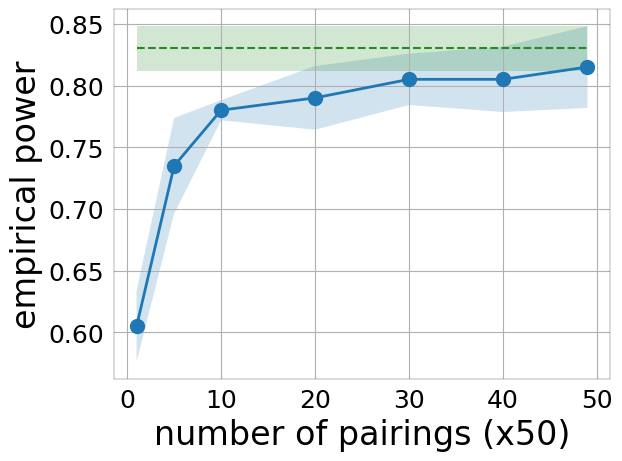

In [99]:
LINEWIDTH = 2
MARKERSIZE = 10
COLOR = 'tab:blue'

plt.plot(n_shuffles, power_avg,
        'o-',
        linewidth = LINEWIDTH,
        markersize = MARKERSIZE,
        color = COLOR,
        label = 'mmd')
plt.fill_between(n_shuffles, power_avg-power_std, power_avg+power_std,
                facecolor = COLOR,
                alpha = 0.2)

plt.hlines(y = mean,
            xmin = 1,
            xmax = 49,
            linestyles = '--',
            color = 'forestgreen',
            label = 'hsic')
plt.fill_between(n_shuffles, mean-std, mean+std,
                facecolor = 'forestgreen',
                alpha = 0.2)


# plt.legend(['MMD', 'HSIC'], ncol=8)
# plt.legend()
plt.grid()
plt.xlabel("number of pairings (x50)", fontsize=24)
plt.ylabel("empirical power", fontsize=24)
#plt.xlim(xmin=90)

plt.rcParams['axes.linewidth'] = 0.2
plt.tick_params(left=False, labelsize=18)
plt.tick_params(bottom=False, labelsize=18)
# plt.savefig(f"plots/hsic_vs_mmd/power_vs_npairs_sinusoid.1f.1d_testsize50.pdf", format="pdf", bbox_inches="tight")